# 🔴 RED ZONE MASTERY PLAYBOOK
## Sideline Decision Support - Coach Ready Visualizations

---

### 📋 EXECUTIVE SUMMARY

**Key Coaching Insights:**
- **SHORT PASSES DOMINATE**: 76.5% completion (0-5 yards) vs 48.4% (16+ yards)
- **BUT DEEP PAYS**: Deep passes have **0.607 EPA** vs 0.085 EPA for short
- **PERFECT PAIRS EXIST**: 10 QB-WR combos with 100% red zone completion
- **COVER 2 ZONE WEAKNESS**: 74.6% completion - highest in red zone
- **PLAY ACTION BOOST**: +6.3% completion, +0.192 EPA in red zone

**Game Plan Strategy:**
1. Use short passes for **high probability** (3rd down, 4th down)
2. Use deep passes for **high value** (1st/2nd down, need TDs not FGs)
3. Target your elite red zone pairs - chemistry matters more than physical tools
4. Attack Cover 2 Zone with seam routes and corners


In [9]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle, Circle, FancyBboxPatch, Arc
from matplotlib.patches import Polygon
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Professional styling for sideline tablets
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk", font_scale=1.2)

# NFL Field Colors
FIELD_GREEN = '#2E7D32'
END_ZONE_BLUE = '#1565C0'
NFL_RED = '#D50A0A'
NFL_YELLOW = '#FFB81C'
WHITE = '#FFFFFF'

print('✅ Libraries loaded - Ready for red zone domination!')

✅ Libraries loaded - Ready for red zone domination!


In [10]:
# Directory of this script: .../NFL-Big-Data-Bowl-2026-Analytics-Challenge
SCRIPT_DIR = Path('C:\\Users\\jrzem\\Downloads\\NFL-Big-Data-Bowl-2026-Analytics-Challenge\\specific analysis\\Two_Minute Drill.ipynb').resolve().parent

# Project root = go up one level from analysis/
PROJECT_ROOT = SCRIPT_DIR.parent

# Data directories
dir = PROJECT_ROOT / "specific analysis" / "data"

# Load red zone data
red_zone_top10 = pd.read_csv(dir/ 'red_zone_top10.csv')
pass_length = pd.read_csv(dir/ 'pass_length_comparison_by_situation.csv')
coverage_heatmap = pd.read_csv(dir/ 'coverage_heatmap_completion_rate.csv', index_col=0)
route_effectiveness = pd.read_csv(dir/ 'route_effectiveness_by_field_position.csv')
play_action = pd.read_csv(dir/ 'play_action_impact_summary.csv')
pass_length = pd.read_csv(dir/ 'pass_length_strategy_by_situation.csv')

# Filter for red zone specific data
red_zone_routes = route_effectiveness[route_effectiveness['field_position'].str.contains('Own', na=False)]

print('✅ Red zone data loaded')
print(f'   → {len(red_zone_top10)} elite QB-WR pairs identified')
print(f'   → {len(red_zone_routes)} route concepts analyzed')

✅ Red zone data loaded
   → 10 elite QB-WR pairs identified
   → 35 route concepts analyzed


---

## 🎯 ELITE RED ZONE QB-WR PAIRS

**These Pairs Have 100% Completion Rate in Red Zone**

Know your weapons! These combinations are money in the red zone:

✅ Elite red zone pairs chart saved


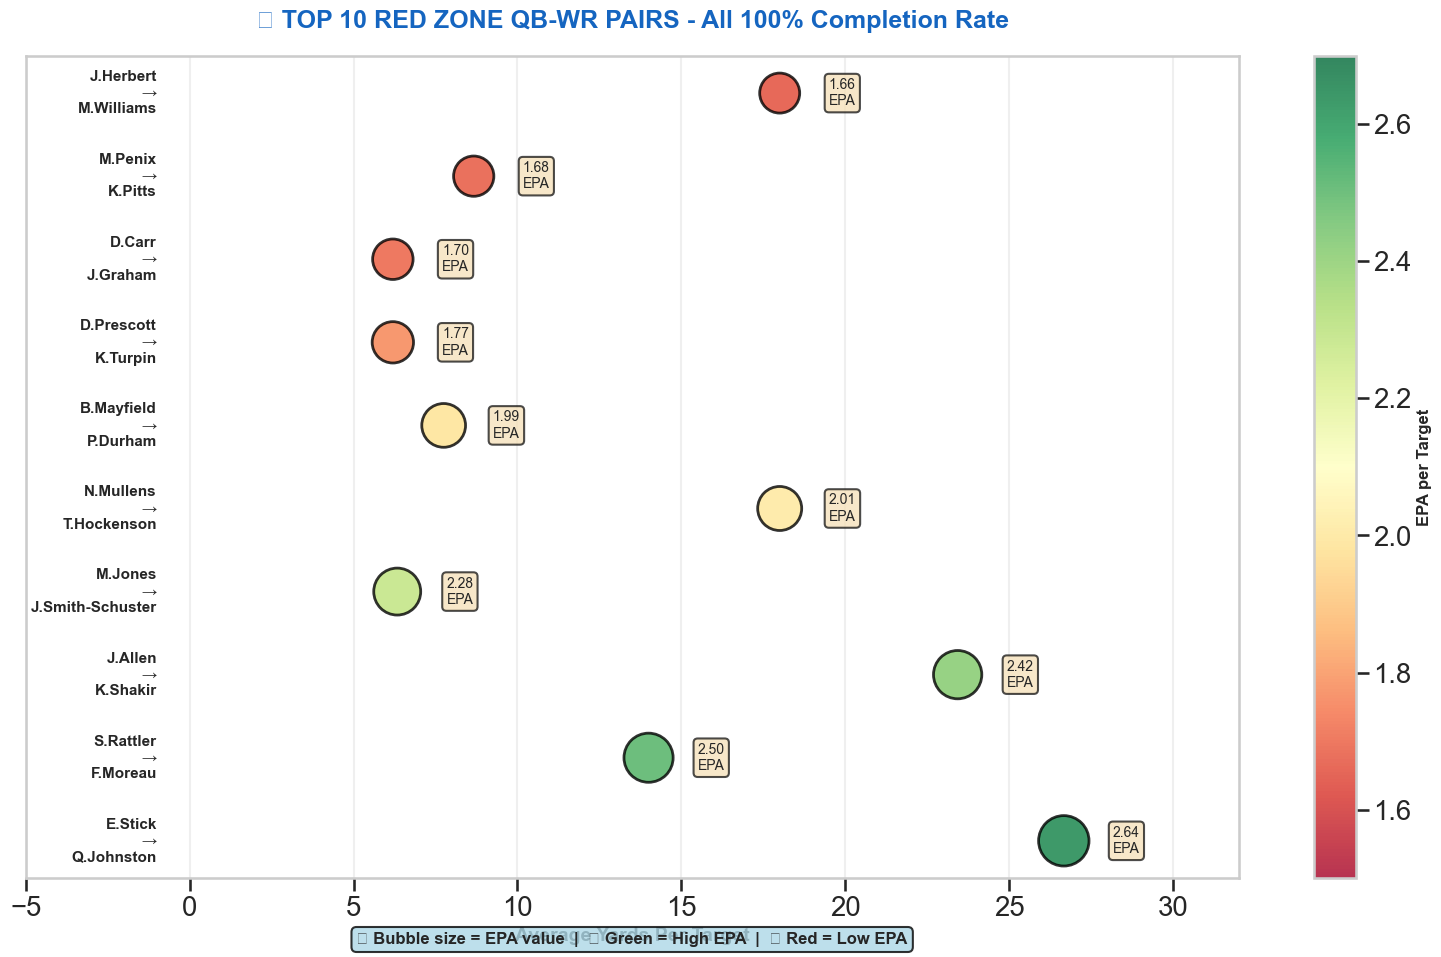

In [11]:
# TOP 10 RED ZONE PAIRS VISUALIZATION
fig, ax = plt.subplots(figsize=(16, 10))

# Prepare data
pairs = red_zone_top10['qb_wr_pair'].str.replace(' → ', '\n→\n')
epa = red_zone_top10['avg_epa']
yards = red_zone_top10['avg_yards']

# Create scatter plot with size based on EPA
scatter = ax.scatter(yards, range(len(pairs)), 
                     s=epa*500,  # Size based on EPA
                     c=epa, cmap='RdYlGn',
                     edgecolors='black', linewidth=2,
                     alpha=0.8, vmin=1.5, vmax=2.7)

# Add pair labels
for i, (pair, yard, ep) in enumerate(zip(pairs, yards, epa)):
    ax.text(-1, i, pair, va='center', ha='right', 
            fontsize=11, weight='bold')
    # Add EPA value next to dot
    ax.text(yard + 1.5, i, f'{ep:.2f}\nEPA', 
            va='center', ha='left', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# Styling
ax.set_xlabel('Average Yards Per Target', fontsize=14, weight='bold')
ax.set_title('🏆 TOP 10 RED ZONE QB-WR PAIRS - All 100% Completion Rate',
             fontsize=18, weight='bold', pad=20, color='#1565C0')
ax.set_yticks([])
ax.set_xlim(-5, 32)
ax.grid(axis='x', alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('EPA per Target', fontsize=12, weight='bold')

# Add legend
legend_text = '🔵 Bubble size = EPA value  |  🟢 Green = High EPA  |  🔴 Red = Low EPA'
plt.text(0.5, -0.08, legend_text, transform=ax.transAxes, 
         ha='center', fontsize=12, weight='bold',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.savefig(dir/ 'red_zone_elite_pairs.png', dpi=300, bbox_inches='tight')
print('✅ Elite red zone pairs chart saved')
plt.show()

---

## 🏈 NFL FIELD DIAGRAM: Pass Depth Strategy

**The Red Zone Paradox:**
- **Short passes** = High completion, low value
- **Deep passes** = Lower completion, HIGH value

**When to use each:**

✅ Red zone field strategy diagram saved


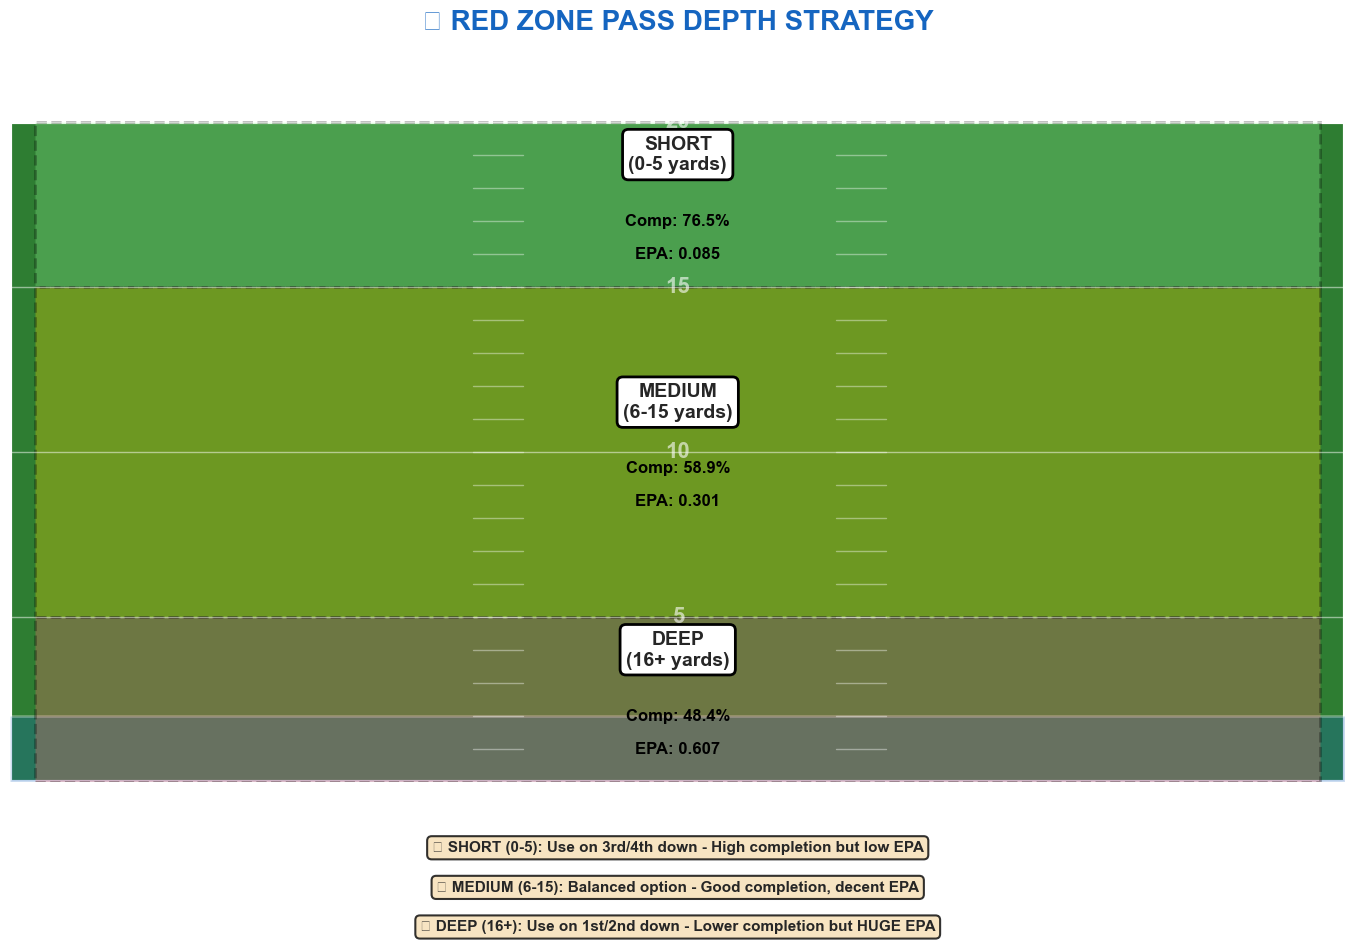

In [12]:
# NFL FIELD VISUALIZATION - RED ZONE STRATEGY
def draw_nfl_field(ax, start_yard=0, end_yard=20):
    """Draw NFL field section for red zone"""
    # Field background
    field = Rectangle((0, 0), 53.33, 20, 
                      facecolor=FIELD_GREEN, edgecolor='white', linewidth=3)
    ax.add_patch(field)
    
    # End zone
    end_zone = Rectangle((0, 0), 53.33, 2, 
                         facecolor=END_ZONE_BLUE, alpha=0.3, edgecolor='white', linewidth=2)
    ax.add_patch(end_zone)
    
    # Yard lines
    for yard in [5, 10, 15, 20]:
        ax.plot([0, 53.33], [yard, yard], 'white', linewidth=1, alpha=0.5)
        # Yard numbers
        ax.text(26.67, yard, str(yard), ha='center', va='center',
                fontsize=16, weight='bold', color='white', alpha=0.6)
    
    # Hash marks
    for yard in range(0, 21):
        ax.plot([18.5, 20.5], [yard, yard], 'white', linewidth=1, alpha=0.4)
        ax.plot([33, 35], [yard, yard], 'white', linewidth=1, alpha=0.4)
    
    ax.set_xlim(0, 53.33)
    ax.set_ylim(0, 22)
    ax.axis('off')

# Create field diagram with pass depth zones
fig, ax = plt.subplots(figsize=(14, 10))
draw_nfl_field(ax)

# Extract red zone pass length data
rz_data = pass_length[pass_length['pass_length'] == 'Red Zone']

# Define zones on field
zones = [
    {'name': 'SHORT\n(0-5 yards)', 'y_range': (15, 20), 'comp': 76.5, 'epa': 0.085, 'color': '#90EE90'},
    {'name': 'MEDIUM\n(6-15 yards)', 'y_range': (5, 15), 'comp': 58.9, 'epa': 0.301, 'color': '#FFD700'},
    {'name': 'DEEP\n(16+ yards)', 'y_range': (0, 5), 'comp': 48.4, 'epa': 0.607, 'color': '#FF6B6B'}
]

# Draw zones with annotations
for zone in zones:
    y_start, y_end = zone['y_range']
    y_mid = (y_start + y_end) / 2
    
    # Zone rectangle
    zone_box = Rectangle((1, y_start), 51.33, y_end - y_start,
                         facecolor=zone['color'], alpha=0.3,
                         edgecolor='black', linewidth=2, linestyle='--')
    ax.add_patch(zone_box)
    
    # Zone label and stats
    ax.text(26.67, y_mid + 1.5, zone['name'],
            ha='center', va='center', fontsize=14, weight='bold',
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', linewidth=2))
    
    ax.text(26.67, y_mid - 0.5, f"Comp: {zone['comp']:.1f}%",
            ha='center', va='center', fontsize=12, weight='bold', color='black')
    
    ax.text(26.67, y_mid - 1.5, f"EPA: {zone['epa']:.3f}",
            ha='center', va='center', fontsize=12, weight='bold', color='black')

# Add title and recommendations
ax.text(26.67, 23, '🏈 RED ZONE PASS DEPTH STRATEGY',
        ha='center', va='center', fontsize=20, weight='bold', color='#1565C0')

# Coaching recommendations
recommendations = [
    '🟢 SHORT (0-5): Use on 3rd/4th down - High completion but low EPA',
    '🟡 MEDIUM (6-15): Balanced option - Good completion, decent EPA',
    '🔴 DEEP (16+): Use on 1st/2nd down - Lower completion but HUGE EPA'
]

for i, rec in enumerate(recommendations):
    ax.text(26.67, -2 - i*1.2, rec,
            ha='center', va='center', fontsize=11, weight='bold',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig(dir/ 'red_zone_field_strategy.png', dpi=300, bbox_inches='tight')
print('✅ Red zone field strategy diagram saved')
plt.show()

---

## 💡 COACHING INSIGHT: The Red Zone Trade-Off

### **High Completion vs High Value**

**Short Passes (0-5 yards):**
- ✅ 76.5% completion rate
- ✅ Safe, predictable gains
- ❌ Only 0.085 EPA
- **USE WHEN:** 3rd down, 4th down, must-have situations

**Deep Passes (16+ yards):**
- ❌ 48.4% completion rate
- ✅ **0.607 EPA** (7x higher than short!)
- ✅ Touchdown potential
- **USE WHEN:** 1st/2nd down, need TDs not FGs, momentum builders

**Strategic Framework:**
```
1st & 10 in Red Zone → Take shot (deep pass)
2nd & Goal → Medium or deep
3rd & Goal → SHORT (high %) or play action deep
4th & Goal → SHORT + Play Action
```


✅ Depth comparison charts saved


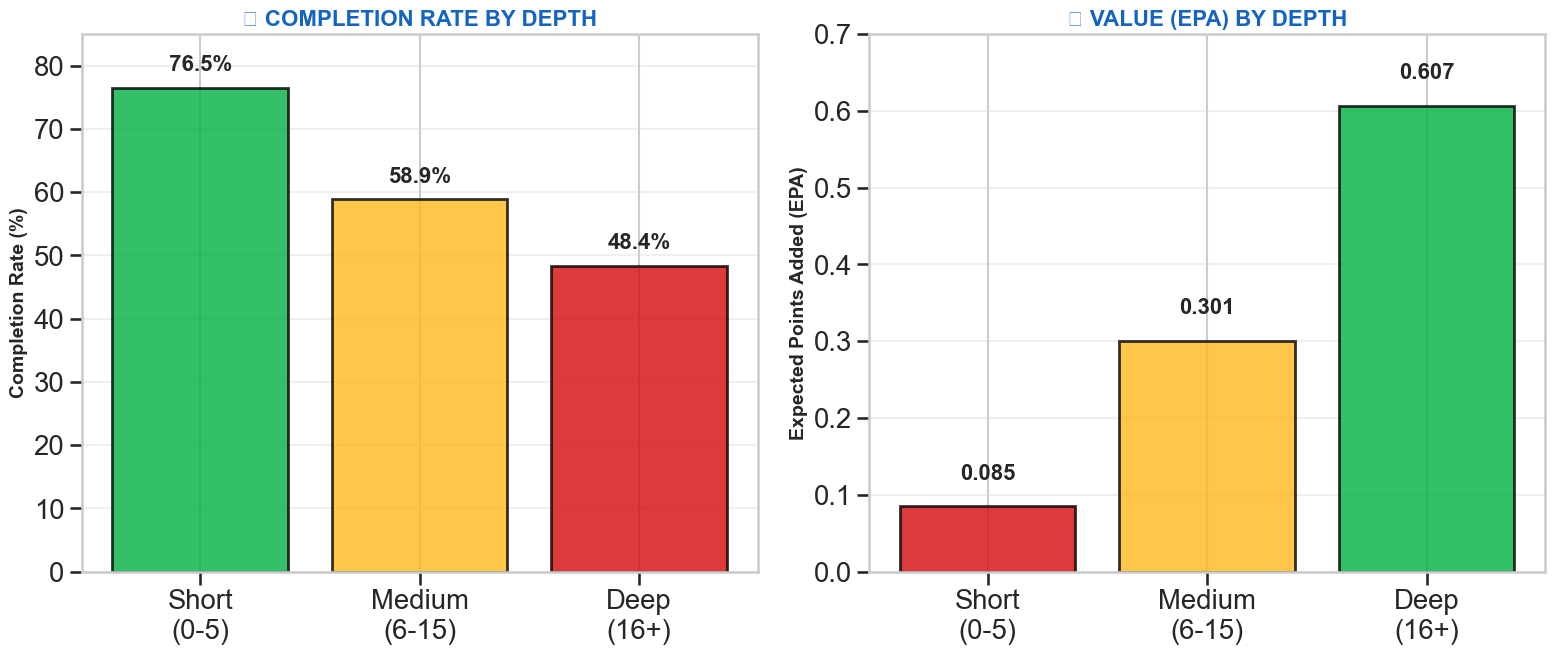

In [13]:
# PASS DEPTH DECISION MATRIX
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Chart 1: Completion Rate Comparison
depths = ['Short\n(0-5)', 'Medium\n(6-15)', 'Deep\n(16+)']
comp_rates = [76.5, 58.9, 48.4]
colors_comp = ['#00B140', '#FFB81C', '#D50A0A']

bars1 = ax1.bar(depths, comp_rates, color=colors_comp, 
                edgecolor='black', linewidth=2, alpha=0.8)

# Add value labels
for bar, val in zip(bars1, comp_rates):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{val:.1f}%', ha='center', va='bottom',
             fontsize=16, weight='bold')

ax1.set_ylabel('Completion Rate (%)', fontsize=14, weight='bold')
ax1.set_title('📊 COMPLETION RATE BY DEPTH', fontsize=16, weight='bold', color='#1565C0')
ax1.set_ylim(0, 85)
ax1.grid(axis='y', alpha=0.3)

# Chart 2: EPA Comparison
epa_values = [0.085, 0.301, 0.607]
colors_epa = ['#D50A0A', '#FFB81C', '#00B140']  # Reversed - higher EPA is better

bars2 = ax2.bar(depths, epa_values, color=colors_epa,
                edgecolor='black', linewidth=2, alpha=0.8)

# Add value labels
for bar, val in zip(bars2, epa_values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.03,
             f'{val:.3f}', ha='center', va='bottom',
             fontsize=16, weight='bold')

ax2.set_ylabel('Expected Points Added (EPA)', fontsize=14, weight='bold')
ax2.set_title('💰 VALUE (EPA) BY DEPTH', fontsize=16, weight='bold', color='#1565C0')
ax2.set_ylim(0, 0.7)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(dir/ 'red_zone_depth_comparison.png', dpi=300, bbox_inches='tight')
print('✅ Depth comparison charts saved')
plt.show()

---

## 🎯 KILL ZONES: Where Successful Passes Occur

**Route Effectiveness in the Red Zone**

✅ Route effectiveness chart saved


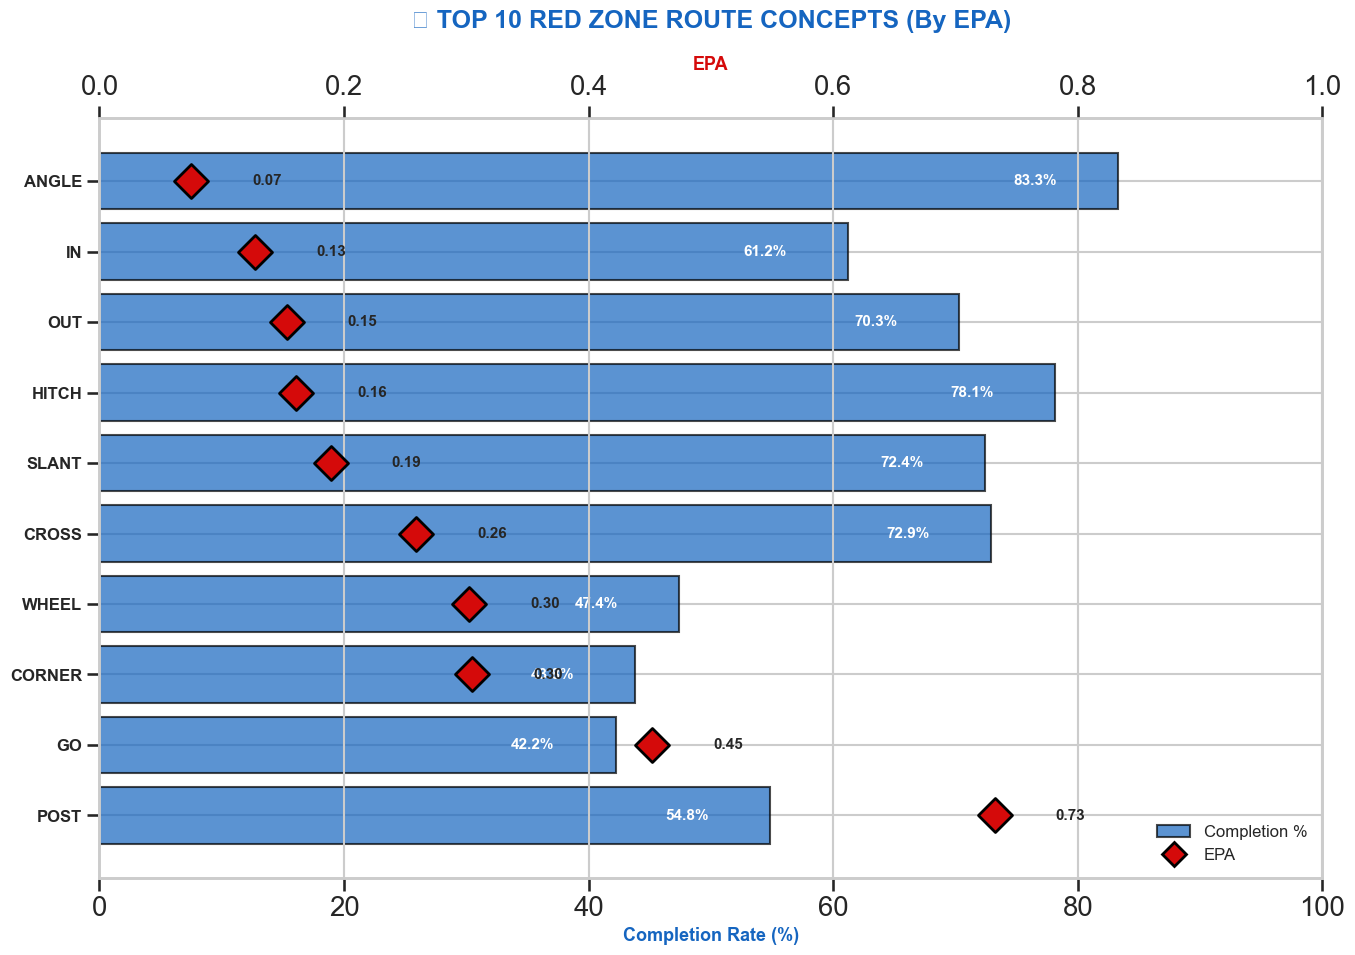

In [14]:
# ROUTE EFFECTIVENESS HEATMAP
fig, ax = plt.subplots(figsize=(14, 10))

# Filter for red zone field positions (we'll use Own 11-25 as proxy for red zone)
rz_routes = route_effectiveness[
    (route_effectiveness['field_position'] == 'Own 11-25') &
    (route_effectiveness['targets'] >= 30)  # Only routes with significant sample
].sort_values('avg_epa', ascending=False)

routes = rz_routes['route'].head(10)
comp_rates = rz_routes['comp_rate'].head(10)
epa_values = rz_routes['avg_epa'].head(10)

# Create horizontal bar chart with dual metrics
y_pos = np.arange(len(routes))

# Create two y-axes
ax2 = ax.twiny()

# Completion rate bars
bars1 = ax.barh(y_pos, comp_rates, alpha=0.7, color='#1565C0', 
                edgecolor='black', linewidth=1.5, label='Completion %')

# EPA markers
ax2.scatter(epa_values, y_pos, s=300, c='#D50A0A', 
            edgecolors='black', linewidth=2, marker='D',
            label='EPA', zorder=3)

# Add value labels
for i, (comp, epa) in enumerate(zip(comp_rates, epa_values)):
    ax.text(comp - 5, i, f'{comp:.1f}%', 
            va='center', ha='right', fontsize=11, weight='bold', color='white')
    ax2.text(epa + 0.05, i, f'{epa:.2f}', 
             va='center', ha='left', fontsize=11, weight='bold')

# Styling
ax.set_yticks(y_pos)
ax.set_yticklabels(routes, fontsize=12, weight='bold')
ax.set_xlabel('Completion Rate (%)', fontsize=13, weight='bold', color='#1565C0')
ax2.set_xlabel('EPA', fontsize=13, weight='bold', color='#D50A0A')
ax.set_title('🎯 TOP 10 RED ZONE ROUTE CONCEPTS (By EPA)',
             fontsize=18, weight='bold', pad=20, color='#1565C0')

ax.set_xlim(0, 100)
ax2.set_xlim(0, 1)
ax.grid(axis='x', alpha=0.3)

# Add legend
legend_elements = [
    plt.Rectangle((0,0),1,1, fc='#1565C0', alpha=0.7, edgecolor='black', label='Completion %'),
    plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='#D50A0A', 
               markersize=12, markeredgecolor='black', markeredgewidth=2, label='EPA')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=12)

plt.tight_layout()
plt.savefig(dir/ 'red_zone_route_effectiveness.png', dpi=300, bbox_inches='tight')
print('✅ Route effectiveness chart saved')
plt.show()

---

## 🛡️ COVERAGE VULNERABILITY: Red Zone Specific

**Which coverages to attack in the red zone:**

✅ Coverage vulnerability chart saved


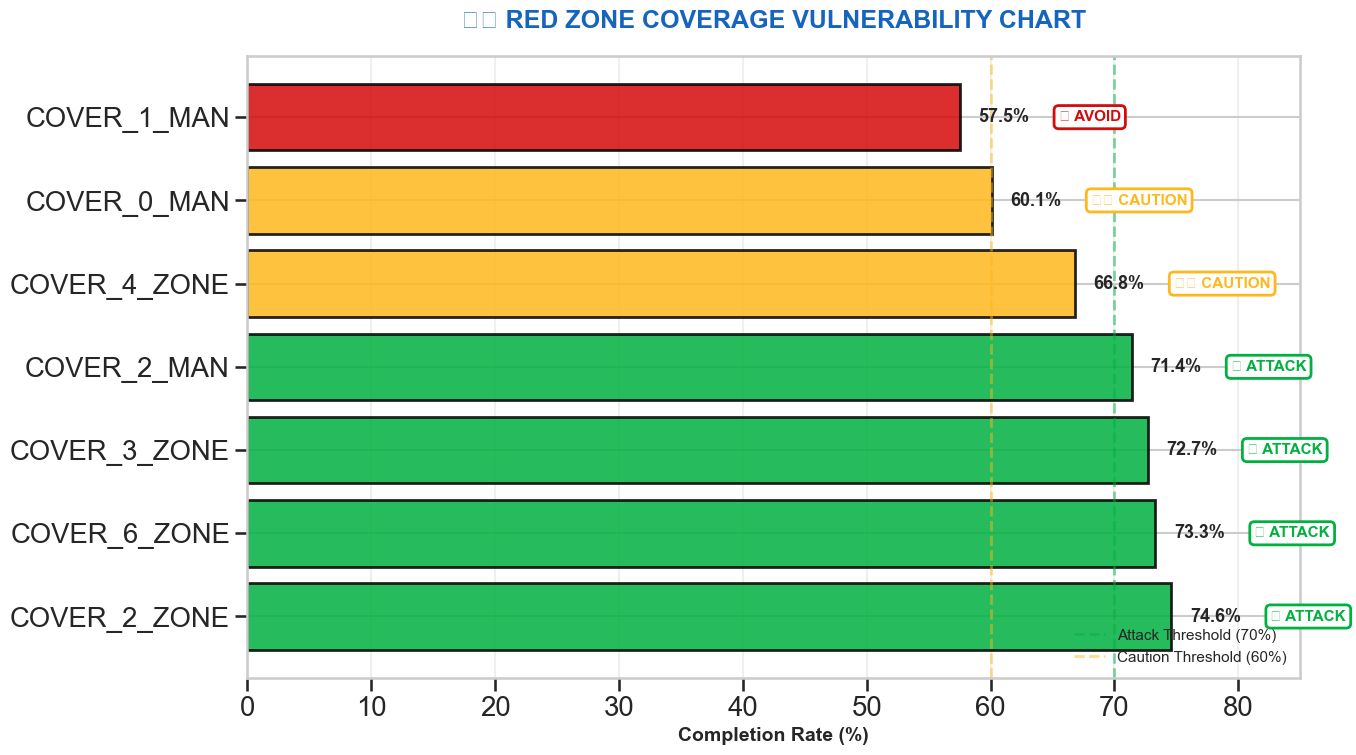

In [15]:
# RED ZONE COVERAGE VULNERABILITY
fig, ax = plt.subplots(figsize=(14, 8))

# Extract red zone coverage data
rz_coverage = coverage_heatmap['Red Zone'].dropna().sort_values(ascending=False)

coverages = rz_coverage.index
comp_rates = rz_coverage.values

# Color code based on success rate
colors_bars = ['#00B140' if x >= 70 else '#FFB81C' if x >= 60 else '#D50A0A' 
               for x in comp_rates]

bars = ax.barh(coverages, comp_rates, color=colors_bars,
               edgecolor='black', linewidth=2, alpha=0.85)

# Add value labels and recommendations
for i, (bar, val) in enumerate(zip(bars, comp_rates)):
    # Completion % label
    ax.text(val + 1.5, i, f'{val:.1f}%', 
            va='center', ha='left', fontsize=13, weight='bold')
    
    # Recommendation
    if val >= 70:
        rec = '✅ ATTACK'
        color = '#00B140'
    elif val >= 60:
        rec = '⚠️ CAUTION'
        color = '#FFB81C'
    else:
        rec = '❌ AVOID'
        color = '#D50A0A'
    
    ax.text(val + 8, i, rec,
            va='center', ha='left', fontsize=11, weight='bold',
            color=color,
            bbox=dict(boxstyle='round', facecolor='white', 
                     edgecolor=color, linewidth=2))

# Styling
ax.set_xlabel('Completion Rate (%)', fontsize=14, weight='bold')
ax.set_title('🛡️ RED ZONE COVERAGE VULNERABILITY CHART',
             fontsize=18, weight='bold', pad=20, color='#1565C0')
ax.set_xlim(0, 85)
ax.grid(axis='x', alpha=0.3)

# Add vertical threshold lines
ax.axvline(70, color='#00B140', linewidth=2, linestyle='--', alpha=0.5, label='Attack Threshold (70%)')
ax.axvline(60, color='#FFB81C', linewidth=2, linestyle='--', alpha=0.5, label='Caution Threshold (60%)')
ax.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig(dir/ 'red_zone_coverage_vulnerability.png', dpi=300, bbox_inches='tight')
print('✅ Coverage vulnerability chart saved')
plt.show()

---

## 🎭 PLAY ACTION IN THE RED ZONE

**Still Effective, But Not Game-Changing Like 4th Down**

✅ Play action comparison saved


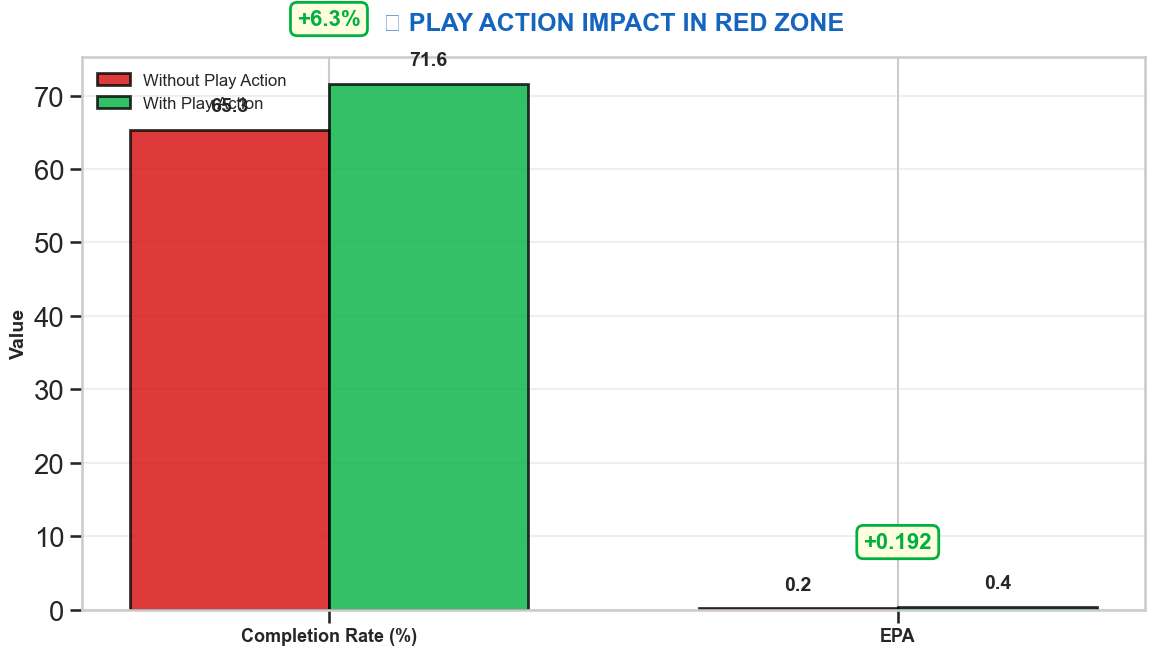

In [16]:
# PLAY ACTION RED ZONE COMPARISON
fig, ax = plt.subplots(figsize=(12, 7))

# Red zone play action data
rz_pa = play_action[play_action['situation'] == 'Red Zone'].iloc[0]

categories = ['Completion Rate (%)', 'EPA']
without_pa = [rz_pa['without_pa_comp_rate'], rz_pa['without_pa_epa']]
with_pa = [rz_pa['with_pa_comp_rate'], rz_pa['with_pa_epa']]

x = np.arange(len(categories))
width = 0.35

bars1 = ax.bar(x - width/2, without_pa, width, label='Without Play Action',
               color='#D50A0A', edgecolor='black', linewidth=2, alpha=0.8)
bars2 = ax.bar(x + width/2, with_pa, width, label='With Play Action',
               color='#00B140', edgecolor='black', linewidth=2, alpha=0.8)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{height:.1f}',
                ha='center', va='bottom', fontsize=14, weight='bold')

# Add improvement annotations
improvements = [
    f"+{rz_pa['comp_rate_improvement']:.1f}%",
    f"+{rz_pa['epa_improvement']:.3f}"
]

for i, imp in enumerate(improvements):
    ax.text(i, max(without_pa[i], with_pa[i]) + 8, imp,
            ha='center', fontsize=16, weight='bold', color='#00B140',
            bbox=dict(boxstyle='round', facecolor='lightyellow', 
                     edgecolor='#00B140', linewidth=2))

# Styling
ax.set_ylabel('Value', fontsize=14, weight='bold')
ax.set_title('🎭 PLAY ACTION IMPACT IN RED ZONE',
             fontsize=18, weight='bold', pad=20, color='#1565C0')
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=13, weight='bold')
ax.legend(fontsize=12, loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(dir/ 'red_zone_play_action.png', dpi=300, bbox_inches='tight')
print('✅ Play action comparison saved')
plt.show()

---

## 🎯 GAME PLAN TAKEAWAYS

### **Red Zone Play Calling Framework:**

**1st & Goal from 10:**
- Take a shot deep (0.607 EPA)
- Even at 48% completion, value is highest
- POST, CORNER, or GO routes
- Consider play action (+6.3% completion)

**2nd & Goal from 6-10:**
- Medium routes (6-15 yards)
- 58.9% completion, 0.301 EPA
- SLANT, CROSS, or IN routes

**3rd & Goal from 1-5:**
- Short passes (0-5 yards)
- 76.5% completion - HIGHEST probability
- FLAT, ANGLE, or SCREEN
- Accept lower EPA for conversion

**4th & Goal from 1-5:**
- Use your elite pairs (100% completion)
- Play action if available (+6.3%)
- Short high-percentage throw

### **Coverage-Specific Adjustments:**

**VS COVER 2 ZONE (74.6% comp):**
- ✅ ATTACK - Best red zone matchup
- Seam routes between safeties
- Corner routes behind CBs
- Stick concepts underneath

**VS COVER 6 ZONE (73.3% comp):**
- ✅ ATTACK - Exploit the half-field coverage
- Attack the quarter-quarter side

**VS COVER 1 MAN (57.5% comp):**
- ⚠️ CAUTION - Lowest red zone success
- Use elite pairs only
- Consider timeout to change play

### **Personnel Decisions:**

**Know Your Elite Pairs:**
Review the top 10 chart - these pairs are 100% in red zone:
- Use them on critical downs (3rd/4th & Goal)
- Chemistry > Physical tools in tight spaces
- Average 1.68 EPA per target (elite value)

**Route Concept Priority (High EPA):**
1. POST routes (0.732 EPA) - Between safeties
2. GO routes (0.452 EPA) - Vertical stretch
3. CORNER routes (0.305 EPA) - Back shoulder
4. WHEEL routes (0.302 EPA) - RB matchup

---

## 📱 SIDELINE QUICK REFERENCE

**Print this for red zone package:**

```
RED ZONE DECISION TREE:

1st & Goal (10 yards):
  → TAKE A SHOT (48% but 0.607 EPA)
  → POST, CORNER, GO routes
  → Add play action (+6.3%)

2nd & Goal (6-10 yards):
  → MEDIUM DEPTH (58.9%, 0.301 EPA)
  → SLANT, CROSS, IN routes

3rd/4th & Goal (1-5 yards):
  → SHORT HIGH % (76.5%)
  → Use elite pairs
  → FLAT, ANGLE, SCREEN
  → Play action if available

VS COVERAGE:
  Cover 2 Zone (74.6%) = ✅ ATTACK
  Cover 6 Zone (73.3%) = ✅ ATTACK  
  Cover 1 Man (57.5%)  = ❌ AVOID
```

---

### 📊 Data Source
Analysis based on 2023 NFL Season (Weeks 1-18, excluding Week 16)  
18,009 plays | 4.5M+ tracking frames | 1,228 QB-WR pairs

**Notebook Generated:** December 17, 2025  
**For:** Coaching Staff - Red Zone Package Development